In [1]:
%%duckdb 

SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
)
LIMIT 5

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,455,1 Ave & E 44 St,40.750020,-73.969053,265,Stanton St & Chrystie St,40.722293,-73.991475,18660,Subscriber,1960.0,2,2015-01-01 00:01:00,2015-01-01 00:24:00,23
1,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
2,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6
3,384,Fulton St & Waverly Ave,40.683178,-73.965964,399,Lafayette Ave & St James Pl,40.688515,-73.964763,19610,Subscriber,1969.0,1,2015-01-01 00:04:00,2015-01-01 00:07:00,3
4,474,5 Ave & E 29 St,40.745168,-73.986831,432,E 7 St & Avenue A,40.726218,-73.983799,20197,Subscriber,1977.0,1,2015-01-01 00:05:00,2015-01-01 00:21:00,16


## Problem 1: Trip duration

### Part 1: Build a Regression Model

Build a regression to predict trip duration by using
- Day of time
- Distance between start and end stations (there might be more than one way to measure it)
- Hour of day
- Weekend indicator
- Don't forget to model bias (this one is intentionally not used in lecture)
- Also any thing you want to end

### Part 2: Experiment Design

- Ensure that you properly design your experiment to report unbiased performance metric you choose

### Part 3 [Optional]: Visualize

- Generate some fictional pickup and dropoff locations for bike trips (random pair selection)
- Estimate trip duration for those say 10 trips
- Visualize them on map using `pydeck` by using redish color for slower trips and greener for faster trips.

# NYC Bisiklet Yolculuğu Süresi Tahmini

Tüm veriyi `dataset` tablosuna aldım. Böylece S3'e bir kez gidip sonraki bütün keşif sorgularını yerelde çalıştırabileceğim.

In [2]:
%%duckdb

CREATE OR REPLACE TABLE dataset AS
(SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
))

,Count
0,23783624


İlk iş: `SUMMARIZE` ile tüm kolonların min/max, null sayısı ve dağılım özetine bakmak. Temizlik kararlarımı buradan çıkaracağım.

In [3]:
%%duckdb

SUMMARIZE dataset

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,start station id,BIGINT,72,3440,836,878.1323107025237,1044.377422601981,327,448,522,23783624,0.00
1,start station name,VARCHAR,1 Ave & E 15 St,York St & Jay St,646,None,None,None,None,None,23783624,0.00
2,start station latitude,DOUBLE,0.0,40.804213,759,40.736920425082026,0.02707894269562298,40.72119672898096,40.73804663111513,40.75210417011886,23783624,0.00
3,start station longitude,DOUBLE,-74.0313720703125,0.0,735,-73.98758094197343,0.030497853678427056,-73.99850226579795,-73.98925165152201,-73.97811841741849,23783624,0.00
4,end station id,BIGINT,72,3440,945,866.0839891347089,1034.2829366987623,326,446,521,23783624,0.00
5,end station name,VARCHAR,1 Ave & E 15 St,York St & Jay St,646,None,None,None,None,None,23783624,0.00
6,end station latitude,DOUBLE,0.0,40.804213,786,40.73637730466588,0.1024576675394409,40.7210447750804,40.7376046144255,40.75188873044308,23783624,0.00
7,end station longitude,DOUBLE,-74.0836394,0.0,735,-73.98732804381176,0.1820819174232946,-73.99879542444937,-73.98946820050595,-73.97857871775125,23783624,0.00
8,bikeid,BIGINT,14529,27342,15156,20358.994452107047,3407.5946041730317,17425,20260,23166,23783624,0.00
9,usertype,VARCHAR,Customer,Subscriber,2,None,None,None,None,None,23783624,0.15


**SUMMARIZE çıktısından ilk gözlemlerim:**

- `duration_min`'de negatif ve çok büyük değerler var
- `birth year`'da 1885 gibi imkansız değerler var
- `usertype` ve `birth year` kolonlarında null değerler var
- Başlangıç ve bitiş noktaları önemli olabilir. Bunu nasıl model eğitimi içerisine alabilirim? Target encoding?

Sonraki hücrelerde bu üç sorunu tek tek ele alacağım.

Önce hedef değişkeni temizlemem gerekiyor. Süreleri kategorilere ayırıp her birinin ne kadar yer tuttuğuna baktım. Şöyle düşündüm: 1 dakikanın altındaki kayıtlar büyük ihtimalle iptal/arıza, 2 saatin üstündekiler ise kilitlemeyi unutma veya kayıp bisiklet. Modelim "normal bir yolculuk ne kadar sürer" sorusuna cevap vermeli, bu uç vakaları öğrenmeye çalışmamalı.

In [4]:
%%duckdb

SELECT
    CASE
        WHEN duration_min < 1     THEN '1) negatif / sıfır'
        WHEN duration_min <= 120  THEN '2) normal (1-120 dk)'
        WHEN duration_min <= 1440 THEN '3) uzun (2-24 saat)'
        ELSE '4) aşırı fazla (>1 gün)'
    END AS kategori,
    count(*)                       AS n,
    round(100.0 * count(*) / sum(count(*)) OVER (), 3) AS yuzde
FROM dataset
GROUP BY 1 ORDER BY 1;

,kategori,n,yuzde
0,1) negatif / sıfır,153,0.001
1,2) normal (1-120 dk),23682743,99.576
2,3) uzun (2-24 saat),94561,0.398
3,4) aşırı fazla (>1 gün),6167,0.026


1–120 dk aralığının veriyi ne kadar temsil ettiğini görmek için persentillere baktım: p99.9 bile 103 dk. Yani 120 dk sınırı neredeyse hiç veri kaybetmeden (satırların %99.6'sı kalıyor) uçları temizliyor. Bu filtreyle devam etme kararı aldım.

In [5]:
%%duckdb

SELECT
    round(quantile_cont(duration_min, 0.50), 1)  AS p50,
    round(quantile_cont(duration_min, 0.90), 1)  AS p90,
    round(quantile_cont(duration_min, 0.95), 1)  AS p95,
    round(quantile_cont(duration_min, 0.99), 1)  AS p99,
    round(quantile_cont(duration_min, 0.999), 1) AS p999
FROM dataset
WHERE duration_min BETWEEN 1 AND 120;

,p50,p90,p95,p99,p999
0,10.0,27.0,33.0,53.0,103.0


SUMMARIZE'da koordinatlarda 0.0 değerleri görmüştüm. NYC için makul bir sınır kutusu (enlem 40.64–40.82, boylam −74.05…−73.90) tanımlayıp dışına düşenleri saydım: toplam 113 satır. Bunları da filtreye ekledim, çünkü mesafe feature'ım koordinatlardan hesaplanacak.

In [6]:
%%duckdb

SELECT
    CASE
        WHEN "start station latitude"  = 0 OR "start station longitude" = 0
          OR "end station latitude"    = 0 OR "end station longitude"   = 0
        THEN '1) sıfır koordinat (0,0)'
        WHEN "start station latitude"  NOT BETWEEN 40.64 AND 40.82
          OR "start station longitude" NOT BETWEEN -74.05 AND -73.90
          OR "end station latitude"    NOT BETWEEN 40.64 AND 40.82
          OR "end station longitude"   NOT BETWEEN -74.05 AND -73.90
        THEN '2) kutu dışı (sıfır değil)'
        ELSE '3) NYC içinde'
    END AS kategori,
    count(*)                                            AS n,
    round(100.0 * count(*) / sum(count(*)) OVER (), 3)  AS yuzde
FROM dataset
WHERE duration_min BETWEEN 1 AND 120
GROUP BY 1 ORDER BY 1;

,kategori,n,yuzde
0,"1) sıfır koordinat (0,0)",90,0.0
1,2) kutu dışı (sıfır değil),23,0.0
2,3) NYC içinde,23682630,100.0


`birth year` kolonunda 1885 gibi imkansız değerler vardı; dağılıma baktım. 1920 öncesi doğumlu görünen 8 binden fazla kayıt ve 2.8M null var.

In [7]:
%%duckdb

SELECT
    count(*) FILTER (WHERE "birth year" < 1920)                AS oncesi_1920,
    count(*) FILTER (WHERE "birth year" BETWEEN 1920 AND 1929) AS y1920ler,
    count(*) FILTER (WHERE "birth year" BETWEEN 1930 AND 1939) AS y1930lar,
    count(*) FILTER (WHERE "birth year" BETWEEN 1940 AND 1949) AS y1940lar,
    count(*) FILTER (WHERE "birth year" BETWEEN 2000 AND 2009) AS y2000ler,
    count(*) FILTER (WHERE "birth year" >= 2010)               AS y2010_sonrasi,
    count(*) FILTER (WHERE "birth year" IS NULL)               AS null_say,
    count(*)                                                   AS toplam
FROM dataset
WHERE duration_min BETWEEN 1 AND 120
  AND "start station latitude"  BETWEEN 40.64 AND 40.82
  AND "start station longitude" BETWEEN -74.05 AND -73.90
  AND "end station latitude"    BETWEEN 40.64 AND 40.82
  AND "end station longitude"   BETWEEN -74.05 AND -73.90;

,oncesi_1920,y1920ler,y1930lar,y1940lar,y2000ler,y2010_sonrasi,null_say,toplam
0,8298,909,14104,261530,6352,0,2835305,23682630


Null'ların rastgele olup olmadığını merak ettim ve `usertype` ile kesiştirdim. Sonuç: birth year null'larının kaynağı neredeyse tamamen Customer (günlük bilet) kullanıcıları onların %98.8'inde doğum yılı yok. Yani eksiklik rastgele değil, kullanıcı tipiyle tamamen ilişkili. Bu yüzden yaş bilgisini modele sokmak yerine, bu bilgiyi zaten taşıyan `usertype`'ı kullanmaya karar verdim.

In [8]:
%%duckdb

SELECT
    COALESCE(usertype, '(null)')                          AS kullanici_tipi,
    count(*)                                              AS n,
    count(*) FILTER (WHERE "birth year" IS NULL)          AS by_null,
    round(100.0 * count(*) FILTER (WHERE "birth year" IS NULL) / count(*), 2) AS by_null_yuzde
FROM dataset
WHERE duration_min BETWEEN 1 AND 120
  AND "start station latitude"  BETWEEN 40.64 AND 40.82
  AND "start station longitude" BETWEEN -74.05 AND -73.90
  AND "end station latitude"    BETWEEN 40.64 AND 40.82
  AND "end station longitude"   BETWEEN -74.05 AND -73.90
GROUP BY 1;

,kullanici_tipi,n,by_null,by_null_yuzde
0,Subscriber,20890422,112523,0.54
1,Customer,2756642,2722728,98.77
2,(null),35566,54,0.15


`usertype`'ın hedefle ilişkisine baktım: Subscriber medyanı 10 dk, Customer 21 dk. Aboneler işe gidip gelen hızlı sürücüler, müşteriler gezinen turistler gibi davranıyor. Bu değişken kesinlikle modele girecek.

In [9]:
%%duckdb

SELECT
    COALESCE(usertype, '(null)')                     AS kullanici_tipi,
    count(*)                                         AS n,
    round(100.0 * count(*) / sum(count(*)) OVER (), 2) AS yuzde,
    round(quantile_cont(duration_min, 0.50), 1)      AS medyan_dk,
    round(avg(ln(duration_min)), 4)                  AS ort_ln
FROM dataset
WHERE duration_min BETWEEN 1 AND 120
  AND "start station latitude"  BETWEEN 40.64 AND 40.82
  AND "start station longitude" BETWEEN -74.05 AND -73.90
  AND "end station latitude"    BETWEEN 40.64 AND 40.82
  AND "end station longitude"   BETWEEN -74.05 AND -73.90
GROUP BY 1 ORDER BY ort_ln;

,kullanici_tipi,n,yuzde,medyan_dk,ort_ln
0,Subscriber,20890422,88.21,10.0,2.2688
1,(null),35566,0.15,20.0,2.8916
2,Customer,2756642,11.64,21.0,2.9579


Yaş gruplarına yine de bir baktım: 18–25 ile 51+ arasındaki ort_ln farkı 0.09, yani etki küçük; "bilinmiyor" grubunun uzun süreleri ise aslında Customer etkisinin tekrarı. `usertype` varken yaşın ek katkısı zayıf, yaşı dışarıda bırakma kararım doğrulanmış oldu.

In [10]:
%%duckdb

SELECT age_group,
       count(*) AS n,
       round(100.0 * count(*) / sum(count(*)) OVER (), 2) AS yuzde,
       round(quantile_cont(duration_min, 0.50), 1)        AS medyan_dk,
       round(avg(ln(duration_min)), 4)                    AS ort_ln
FROM (
    SELECT duration_min,
    CASE
        WHEN "birth year" NOT BETWEEN 1930 AND 2002 OR "birth year" IS NULL
            THEN 'bilinmiyor'
        WHEN extract('year' FROM start_at) - "birth year" <= 25 THEN '18-25'
        WHEN extract('year' FROM start_at) - "birth year" <= 35 THEN '26-35'
        WHEN extract('year' FROM start_at) - "birth year" <= 50 THEN '36-50'
        ELSE '51+'
    END AS age_group
    FROM dataset
    WHERE duration_min BETWEEN 1 AND 120
      AND "start station latitude"  BETWEEN 40.64 AND 40.82
      AND "start station longitude" BETWEEN -74.05 AND -73.90
      AND "end station latitude"    BETWEEN 40.64 AND 40.82
      AND "end station longitude"   BETWEEN -74.05 AND -73.90
) GROUP BY 1 ORDER BY 1;

,age_group,n,yuzde,medyan_dk,ort_ln
0,18-25,2249171,9.50,9.0,2.2342
1,26-35,8000760,33.78,10.0,2.2551
2,36-50,6950556,29.35,10.0,2.2700
3,51+,3637631,15.36,10.0,2.3222
4,bilinmiyor,2844512,12.01,20.0,2.9395


Mesafe feature'ı için haversine formülünü SQL'de yazdım: istasyon koordinatlarından kuş uçuşu km. Ayrıca başlangıç istasyonu = bitiş istasyonu olan "tur sürüşlerini" ayrı bir bayrakla işaretledim, çünkü bunlarda mesafe 0 ama süre 0 değil, modeli yanıltabilirler.

In [11]:
%%duckdb

SELECT
    "start station latitude", "end station latitude", "start station longitude", "end station longitude",
    6371 * 2 * asin(sqrt(
        pow(sin(radians("end station latitude"  - "start station latitude")  / 2), 2) +
        cos(radians("start station latitude")) * cos(radians("end station latitude")) *
        pow(sin(radians("end station longitude" - "start station longitude") / 2), 2)
    )) AS distance_km,
    CASE WHEN "start station id" = "end station id" THEN 1 ELSE 0 END AS round_trip
FROM dataset
WHERE duration_min BETWEEN 1 AND 120
  AND "start station latitude"  BETWEEN 40.64 AND 40.82
  AND "start station longitude" BETWEEN -74.05 AND -73.90
  AND "end station latitude"    BETWEEN 40.64 AND 40.82
  AND "end station longitude"   BETWEEN -74.05 AND -73.90
limit 10;

,start station latitude,end station latitude,start station longitude,end station longitude,distance_km,round_trip
0,40.750020,40.722293,-73.969053,-73.991475,3.615820,0
1,40.743174,40.739355,-74.003664,-73.999318,0.560745,0
2,40.740964,40.749013,-73.986022,-73.988484,0.918719,0
3,40.683178,40.688515,-73.965964,-73.964763,0.602053,0
4,40.745168,40.726218,-73.986831,-73.983799,2.122555,0
5,40.750073,40.735238,-73.998393,-74.000271,1.657115,0
6,40.748549,40.745168,-73.988084,-73.986831,0.390487,0
7,40.739323,40.738177,-74.008119,-73.977387,2.592390,0
8,40.762272,40.756458,-73.987882,-73.993722,0.812327,0
9,40.748238,40.738177,-73.978311,-73.977387,1.121495,0


Mesafe dağılımını kontrol ettim: medyan 1.4 km, p99 6.4 km, tur sürüşleri toplamın %2'si. Değerler şehir içi bisiklet için makul görünüyor.

In [12]:
%%duckdb

WITH d AS (
    SELECT
        6371 * 2 * asin(sqrt(
            pow(sin(radians("end station latitude"  - "start station latitude")  / 2), 2) +
            cos(radians("start station latitude")) * cos(radians("end station latitude")) *
            pow(sin(radians("end station longitude" - "start station longitude") / 2), 2)
        )) AS distance_km,
        CASE WHEN "start station id" = "end station id" THEN 1 ELSE 0 END AS round_trip
    FROM dataset
    WHERE duration_min BETWEEN 1 AND 120
      AND "start station latitude"  BETWEEN 40.64 AND 40.82
      AND "start station longitude" BETWEEN -74.05 AND -73.90
      AND "end station latitude"    BETWEEN 40.64 AND 40.82
      AND "end station longitude"   BETWEEN -74.05 AND -73.90
)
SELECT
    count(*) FILTER (WHERE round_trip = 1)                AS tur_surusu,
    round(100.0 * count(*) FILTER (WHERE round_trip = 1) / count(*), 2) AS tur_yuzde,
    round(quantile_cont(distance_km, 0.50), 3)           AS medyan_km,
    round(quantile_cont(distance_km, 0.90), 3)           AS p90_km,
    round(quantile_cont(distance_km, 0.99), 3)           AS p99_km,
    round(max(distance_km), 3)                           AS max_km
FROM d;

,tur_surusu,tur_yuzde,medyan_km,p90_km,p99_km,max_km
0,473436,2.0,1.408,3.505,6.372,18.002


Süreyi ve mesafeyi ham ölçekte mi, log ölçekte mi kullanmalıyım? Dört kombinasyonun korelasyonunu karşılaştırdım. log-log 0.771 ile açık ara en yüksek iki değişken de sağa çarpık olduğu için beklenen bir sonuç. Buradan iki karar çıkardım: hedefim `ln(duration_min)` olacak ve mesafeyi de `ln(distance_km)` olarak kullanacağım (ham `distance_km`'yi de yanına ekleyip seçimi modele bırakıyorum).

In [13]:
%%duckdb

WITH d AS (
    SELECT
        duration_min,
        6371 * 2 * asin(sqrt(
            pow(sin(radians("end station latitude"  - "start station latitude")  / 2), 2) +
            cos(radians("start station latitude")) * cos(radians("end station latitude")) *
            pow(sin(radians("end station longitude" - "start station longitude") / 2), 2)
        )) AS distance_km
    FROM dataset
    WHERE duration_min BETWEEN 1 AND 120
      AND "start station latitude"  BETWEEN 40.64 AND 40.82
      AND "start station longitude" BETWEEN -74.05 AND -73.90
      AND "end station latitude"    BETWEEN 40.64 AND 40.82
      AND "end station longitude"   BETWEEN -74.05 AND -73.90
      AND "start station id" <> "end station id"    
      AND distance_km > 0                            
)
SELECT
    round(corr(distance_km, duration_min), 4)            AS ham_ham,
    round(corr(distance_km, ln(duration_min)), 4)        AS ham_logsure,
    round(corr(ln(distance_km), ln(duration_min)), 4)    AS log_log,
    round(corr(ln(distance_km), duration_min), 4)        AS logmesafe_hamsure
FROM d;

,ham_ham,ham_logsure,log_log,logmesafe_hamsure
0,0.6472,0.7142,0.771,0.6011


Saat etkisi: sabahın erken saatlerinde medyan 8 dk'ya düşüyor, gün içinde uzuyor. Saat döngüsel bir değişken (23 ile 0 komşu), bu yüzden one-hot yerine sin/cos dönüşümüyle temsil etmeye karar verdim  2 kolonla hem sürekliliği hem döngüselliği koruyorum.

In [14]:
%%duckdb

SELECT
    extract('hour' FROM start_at)            AS saat,
    count(*)                                 AS n,
    round(quantile_cont(duration_min, 0.50), 1) AS medyan_dk,
    round(avg(ln(duration_min)), 4)          AS ort_ln
FROM dataset
WHERE duration_min BETWEEN 1 AND 120
  AND "start station latitude"  BETWEEN 40.64 AND 40.82
  AND "start station longitude" BETWEEN -74.05 AND -73.90
  AND "end station latitude"    BETWEEN 40.64 AND 40.82
  AND "end station longitude"   BETWEEN -74.05 AND -73.90
GROUP BY 1 ORDER BY 1;

,saat,n,medyan_dk,ort_ln
0,0,218656,10.0,2.2633
1,1,120119,9.0,2.2431
2,2,70318,9.0,2.2362
3,3,44028,9.0,2.2124
4,4,41911,9.0,2.1578
5,5,132834,8.0,2.1012
6,6,511891,8.0,2.1290
7,7,1083477,9.0,2.2304
8,8,1922618,10.0,2.3042
9,9,1520041,10.0,2.2874


Hafta sonu medyan 12 dk, hafta içi 10 dk. weekend indicator'ı 0/1 bayrak olarak ekliyorum.

In [15]:
%%duckdb

SELECT
    extract('dow' FROM start_at)             AS gun,   -- 0=Pazar ... 6=Cumartesi
    CASE WHEN extract('dow' FROM start_at) IN (0,6) THEN 'haftasonu' ELSE 'haftaici' END AS tip,
    count(*)                                 AS n,
    round(quantile_cont(duration_min, 0.50), 1) AS medyan_dk,
    round(avg(ln(duration_min)), 4)          AS ort_ln
FROM dataset
WHERE duration_min BETWEEN 1 AND 120
  AND "start station latitude"  BETWEEN 40.64 AND 40.82
  AND "start station longitude" BETWEEN -74.05 AND -73.90
  AND "end station latitude"    BETWEEN 40.64 AND 40.82
  AND "end station longitude"   BETWEEN -74.05 AND -73.90
GROUP BY 1, 2 ORDER BY 1;

,gun,tip,n,medyan_dk,ort_ln
0,0,haftasonu,2693972,12.0,2.4517
1,1,haftaici,3429699,10.0,2.3285
2,2,haftaici,3616690,10.0,2.3083
3,3,haftaici,3824946,10.0,2.3149
4,4,haftaici,3744202,10.0,2.3127
5,5,haftaici,3553111,10.0,2.3295
6,6,haftasonu,2820010,12.0,2.4554


Ay bazında güçlü bir mevsimsellik var: kışın 9 dk, yazın 11–12 dk. Şöyle düşündüm: bu etkinin asıl kaynağı takvim değil, hava durumu. O zaman ay yerine doğrudan sıcaklık/yağış verisini eklemek hem daha açıklayıcı hem daha genellenebilir olur.

In [16]:
%%duckdb

SELECT
    extract('month' FROM start_at)           AS ay,
    count(*)                                 AS n,
    round(quantile_cont(duration_min, 0.50), 1) AS medyan_dk,
    round(avg(ln(duration_min)), 4)          AS ort_ln
FROM dataset
WHERE duration_min BETWEEN 1 AND 120
  AND "start station latitude"  BETWEEN 40.64 AND 40.82
  AND "start station longitude" BETWEEN -74.05 AND -73.90
  AND "end station latitude"    BETWEEN 40.64 AND 40.82
  AND "end station longitude"   BETWEEN -74.05 AND -73.90
GROUP BY 1 ORDER BY 1;

,ay,n,medyan_dk,ort_ln
0,1,792895,9.0,2.1601
1,2,755323,9.0,2.1742
2,3,1256003,10.0,2.2698
3,4,1656646,10.0,2.3384
4,5,2161998,11.0,2.3988
5,6,2392765,11.0,2.3932
6,7,2455726,11.0,2.4037
7,8,2725189,11.0,2.4146
8,9,2924726,11.0,2.4101
9,10,2774088,11.0,2.3529


Open-Meteo arşiv API'sinden NYC (40.74, −73.99) için 2015–2016 saatlik sıcaklık ve yağış verisini çektim

In [17]:
%%duckdb

CREATE OR REPLACE TABLE weather AS
WITH raw AS (
    SELECT *
    FROM read_json_auto(
        'https://archive-api.open-meteo.com/v1/archive?latitude=40.74&longitude=-73.99&start_date=2015-01-01&end_date=2016-12-31&hourly=temperature_2m,precipitation&timezone=America%2FNew_York'
    )
)
SELECT
    unnest(hourly.time)::TIMESTAMP        AS weather_hour,
    unnest(hourly.temperature_2m)         AS temperature_c,
    unnest(hourly.precipitation)          AS precip_mm
FROM raw;

SELECT
    count(*)                          AS saat_sayisi,
    min(weather_hour)                 AS ilk,
    max(weather_hour)                 AS son,
    round(min(temperature_c), 1)      AS min_sic,
    round(max(temperature_c), 1)      AS max_sic
FROM weather;

,saat_sayisi,ilk,son,min_sic,max_sic
0,17544,2015-01-01,2016-12-31 23:00:00,-19.8,35.0


API'ye tekrar gitmemek için hava verisini parquet'e yedekledim.

In [18]:
%%duckdb

COPY weather TO 'weather.parquet' (FORMAT PARQUET);

,Count
0,17544


In [19]:
%%duckdb
SET preserve_insertion_order = false;
SET max_temp_directory_size = '50GiB';
SET threads = 4;

,Success


Ana birleştirme: her yolculuğu başlangıç zamanını saate yuvarlayarak hava durumu tablosuyla LEFT JOIN'ledim. Aynı sorguda daha önce kararlaştırdığım tüm temizlik filtrelerini, haversine mesafeyi, yağmur bayrağını (yağış > 0.1mm) ve tur sürüşü işaretini uyguladım.

In [20]:
%%duckdb

CREATE OR REPLACE TABLE trips_weather AS
SELECT
    d.duration_min,
    d.start_at,
    d."start station name"  AS start_station,
    d.usertype,                                    
    w.temperature_c,
    w.precip_mm,
    CASE WHEN w.precip_mm > 0.1 THEN 1 ELSE 0 END AS is_raining,
    6371 * 2 * asin(sqrt(
        pow(sin(radians(d."end station latitude"  - d."start station latitude")  / 2), 2) +
        cos(radians(d."start station latitude")) * cos(radians(d."end station latitude")) *
        pow(sin(radians(d."end station longitude" - d."start station longitude") / 2), 2)
    )) AS distance_km,
    CASE WHEN d."start station id" = d."end station id" THEN 1 ELSE 0 END AS round_trip
FROM dataset AS d
LEFT JOIN weather AS w
  ON date_trunc('hour', d.start_at) = w.weather_hour
WHERE d.duration_min BETWEEN 1 AND 120
  AND d."start station latitude"  BETWEEN 40.64 AND 40.82
  AND d."start station longitude" BETWEEN -74.05 AND -73.90
  AND d."end station latitude"    BETWEEN 40.64 AND 40.82
  AND d."end station longitude"   BETWEEN -74.05 AND -73.90;

,Count
0,23682630


In [21]:
%%duckdb

COPY trips_weather TO 'trips_weather.parquet' (FORMAT PARQUET);

,Count
0,23682630


Join sonrası sağlama: satır sayısı, ortalama mesafe, tur ve subscriber sayıları beklediğim değerlerde mi diye kontrol ettim.

In [22]:
%%duckdb

SELECT
    count(*)                                        AS toplam,
    round(avg(distance_km), 3)                      AS ort_mesafe,
    sum(round_trip)                                 AS tur_sayisi,
    count(*) FILTER (WHERE usertype = 'Subscriber') AS subscriber_n,
    count(*) FILTER (WHERE usertype IS NULL)        AS usertype_null
FROM trips_weather;

,toplam,ort_mesafe,tur_sayisi,subscriber_n,usertype_null
0,23682630,1.768,473436.0,20890422,35566


Hava verisi eşleşmeyen satır var mı diye baktım: 0 null. Join tam oturmuş.

In [23]:
%%duckdb

SELECT
    count(*)                                       AS toplam,
    count(*) FILTER (WHERE temperature_c IS NULL)  AS hava_null,
    round(100.0 * count(*) FILTER (WHERE temperature_c IS NULL) / count(*), 4) AS null_yuzde
FROM trips_weather;

,toplam,hava_null,null_yuzde
0,23682630,0,0.0


Sıcaklık etkisi: donma altında medyan 8 dk, 28°C üstünde 12 dk. Soğukta insanlar ya hızlı sürüyor ya kısa yolculuk yapıyor. Sıcaklığı sürekli değişken olarak modele alıyorum.

In [24]:
%%duckdb

SELECT
    CASE
        WHEN temperature_c < 0   THEN '1) <0 (donma)'
        WHEN temperature_c < 10  THEN '2) 0-10 (soğuk)'
        WHEN temperature_c < 20  THEN '3) 10-20 (ılıman)'
        WHEN temperature_c < 28  THEN '4) 20-28 (sıcak)'
        ELSE '5) 28+ (çok sıcak)'
    END AS sicaklik_grubu,
    count(*)                                     AS n,
    round(quantile_cont(duration_min, 0.50), 1)  AS medyan_dk,
    round(avg(ln(duration_min)), 4)              AS ort_ln
FROM trips_weather
GROUP BY 1 ORDER BY 1;

,sicaklik_grubu,n,medyan_dk,ort_ln
0,1) <0 (donma),1103228,8.0,2.1276
1,2) 0-10 (soğuk),4449453,9.0,2.2272
2,3) 10-20 (ılıman),7643515,10.0,2.3502
3,4) 20-28 (sıcak),8247936,11.0,2.4205
4,5) 28+ (çok sıcak),2238498,12.0,2.4430


Yağmur, sezgimin tersine süreyi kısaltıyor (medyan 10 vs 11 dk)  yağmurda keyif turu değil, mecburi yolculuk yapılıyor herhalde. Etki küçük ama yine de bayrak olarak ekliyorum. 

In [25]:
%%duckdb

SELECT
    is_raining,
    count(*)                                     AS n,
    round(quantile_cont(duration_min, 0.50), 1)  AS medyan_dk,
    round(avg(ln(duration_min)), 4)              AS ort_ln
FROM trips_weather
GROUP BY 1 ORDER BY 1;

,is_raining,n,medyan_dk,ort_ln
0,0,22026515,11.0,2.3548
1,1,1656115,10.0,2.2859


İstasyon etkisini de değerlendirdim: 1000+ yolculuğu olan istasyonlar arasında ort_ln aralığı 1.69 lokasyon ciddi bilgi taşıyor.

In [26]:
%%duckdb

WITH istasyon_ort AS (
    SELECT
        "start_station"            AS istasyon,
        count(*)                        AS n,
        avg(ln(duration_min))           AS ort_ln
    FROM trips_weather
    GROUP BY 1
    HAVING count(*) >= 1000              
)
SELECT
    count(*)                            AS istasyon_sayisi,
    round(min(ort_ln), 4)               AS en_dusuk,
    round(max(ort_ln), 4)               AS en_yuksek,
    round(max(ort_ln) - min(ort_ln), 4) AS aralik,
    round(stddev(ort_ln), 4)            AS std_sapma
FROM istasyon_ort;

,istasyon_sayisi,en_dusuk,en_yuksek,aralik,std_sapma
0,639,1.6826,3.3757,1.6932,0.2193


Ama 675 istasyon var ve bir kısmının çok az yolculuğu var. 675 kolonluk one-hot kolon sayısını gereksiz şişirir; temel feature'larla kalıp istasyonu dışarıda bırakmayı seçtim. (İyileştirme notu: ileride target encoding ile denenebilir.)

In [27]:
%%duckdb

WITH istasyon_n AS (
    SELECT start_station, count(*) AS n
    FROM trips_weather
    GROUP BY 1
)
SELECT
    count(*)                                          AS toplam_istasyon,
    count(*) FILTER (WHERE n >= 1000)                 AS buyuk_1000_ustu,
    count(*) FILTER (WHERE n BETWEEN 100 AND 999)     AS orta_100_999,
    count(*) FILTER (WHERE n < 100)                   AS kucuk_100_alti,
    round(100.0 * count(*) FILTER (WHERE n < 100) / count(*), 2) AS kucuk_yuzde,
    min(n)                                            AS en_az_yolculuk,
    round(quantile_cont(n, 0.50), 0)                  AS medyan_yolculuk
FROM istasyon_n;

,toplam_istasyon,buyuk_1000_ustu,orta_100_999,kucuk_100_alti,kucuk_yuzde,en_az_yolculuk,medyan_yolculuk
0,675,639,23,13,1.93,1,20619.0


Feature adaylarımın hedefle (ln süre) tekil korelasyonlarına topluca baktım: `ln_distance` 0.77 ile ana taşıyıcı, `is_subscriber` 0.31 ile ikinci; kalanlar küçük ama sıfırdan farklı katkılar.

In [28]:
%%duckdb

WITH f AS (
    SELECT
        ln(duration_min)                                          AS y,
        distance_km,
        CASE WHEN round_trip = 1 THEN NULL ELSE ln(distance_km) END AS ln_distance, 
        temperature_c,
        precip_mm,
        is_raining,
        round_trip,
        CASE WHEN usertype = 'Subscriber' THEN 1 ELSE 0 END       AS is_subscriber,  
        CASE WHEN extract('dow' FROM start_at) IN (0,6) THEN 1 ELSE 0 END AS is_weekend,
        sin(2*pi()*extract('hour' FROM start_at)/24)              AS hour_sin,
        cos(2*pi()*extract('hour' FROM start_at)/24)              AS hour_cos
    FROM trips_weather
)
SELECT
    round(corr(y, distance_km),    4) AS distance_ham,
    round(corr(y, ln_distance),    4) AS distance_log,
    round(corr(y, temperature_c),  4) AS temp,
    round(corr(y, is_subscriber),  4) AS subscriber,
    round(corr(y, precip_mm),      4) AS precip,
    round(corr(y, is_raining),     4) AS rain_flag,
    round(corr(y, round_trip),     4) AS round_trip,
    round(corr(y, is_weekend),     4) AS weekend,
    round(corr(y, hour_sin),       4) AS hour_sin,
    round(corr(y, hour_cos),       4) AS hour_cos
FROM f;

,distance_ham,distance_log,temp,subscriber,precip,rain_flag,round_trip,weekend,hour_sin,hour_cos
0,0.6704,0.771,0.1239,-0.3053,-0.0194,-0.0242,0.0432,0.0785,-0.0578,-0.0427


Çoklu doğrusallık kontrolü: feature çiftlerinin birbiriyle korelasyonuna baktım. En yükseği `is_raining`–`precip_mm` (0.66); ikisinden sadece `is_raining`'i tutuyorum. `distance`–`round_trip` (−0.19) kabul edilebilir düzeyde. `is_subscriber` hiçbir feature'la örtüşmüyor, yani hedefle olan güçlü ilişkisi kendine ait bilgi.

In [29]:
%%duckdb

WITH f AS (
    SELECT
        distance_km,
        temperature_c,
        precip_mm,
        is_raining,
        CASE WHEN extract('dow' FROM start_at) IN (0,6) THEN 1 ELSE 0 END AS is_weekend,
        round_trip,
        CASE WHEN usertype = 'Subscriber' THEN 1 ELSE 0 END              AS is_subscriber, 
        sin(2*pi()*extract('hour' FROM start_at)/24)                     AS hour_sin,
        cos(2*pi()*extract('hour' FROM start_at)/24)                     AS hour_cos
    FROM trips_weather
)
SELECT
    round(corr(is_raining, precip_mm), 4)          AS rain_vs_precip,
    round(corr(distance_km, round_trip), 4)        AS dist_vs_roundtrip,
    round(corr(temperature_c, precip_mm), 4)       AS temp_vs_precip,
    round(corr(temperature_c, is_weekend), 4)      AS temp_vs_weekend,
    -- is_subscriber örtüşme kontrolleri:
    round(corr(is_subscriber, is_weekend), 4)      AS sub_vs_weekend,
    round(corr(is_subscriber, round_trip), 4)      AS sub_vs_roundtrip,
    round(corr(is_subscriber, hour_sin), 4)        AS sub_vs_hoursin,
    round(corr(is_subscriber, hour_cos), 4)        AS sub_vs_hourcos,
    round(corr(is_subscriber, distance_km), 4)     AS sub_vs_distance
FROM f;

,rain_vs_precip,dist_vs_roundtrip,temp_vs_precip,temp_vs_weekend,sub_vs_weekend,sub_vs_roundtrip,sub_vs_hoursin,sub_vs_hourcos,sub_vs_distance
0,0.6577,-0.1926,0.0415,0.0356,-0.1837,-0.1144,0.0707,0.0791,-0.0319


Artık final feature tablosunu kuruyorum. Tur sürüşlerinde distance = 0 olduğundan ln(0) = −∞ patlar. Çözümüm: `ln_distance`'ı tur sürüşlerinde 0'a sabitleyip `round_trip` bayrağını ayrıca modele vermek bu grubun düzeltmesini bayrağın katsayısı üstlenecek.

In [30]:
%%duckdb

CREATE OR REPLACE TABLE features AS
SELECT
    duration_min,                                     
    ln(duration_min) AS y_log,                        

    CASE WHEN round_trip = 1 THEN 0
         ELSE ln(distance_km) END   AS ln_distance,
    distance_km,                                      

    temperature_c,                                    
    round_trip,                                       
    is_raining,                                       

    CASE WHEN usertype = 'Subscriber' THEN 1 ELSE 0 END AS is_subscriber,

    CASE WHEN extract('dow' FROM start_at) IN (0,6)
         THEN 1 ELSE 0 END          AS is_weekend,

    sin(2*pi()*extract('hour' FROM start_at)/24) AS hour_sin,
    cos(2*pi()*extract('hour' FROM start_at)/24) AS hour_cos,

    start_station,                                    
    start_at                                         
FROM trips_weather;

,Count
0,23682630


Hedefte null yok, `ln_distance`'ta null/sonsuz yok, tur sürüşlerinin hepsinde ln_distance = 0. Tablo tutarlı.

In [31]:
%%duckdb

SELECT
    count(*)                                          AS toplam,
    count(*) FILTER (WHERE y_log IS NULL)             AS hedef_null,
    round(avg(y_log), 4)                              AS ort_ylog,
    round(avg(distance_km), 3)                        AS ort_mesafe,
    round(avg(temperature_c), 1)                      AS ort_sicaklik,

    sum(is_subscriber)                                AS subscriber_n,
    round(100.0 * sum(is_subscriber) / count(*), 2)   AS subscriber_yuzde,
    count(*) FILTER (WHERE ln_distance IS NULL)        AS lndist_null,
    count(*) FILTER (WHERE NOT isfinite(ln_distance))  AS lndist_sonsuz,
    count(*) FILTER (WHERE round_trip = 1 AND ln_distance <> 0) AS tur_lndist_hata
FROM features;

,toplam,hedef_null,ort_ylog,ort_mesafe,ort_sicaklik,subscriber_n,subscriber_yuzde,lndist_null,lndist_sonsuz,tur_lndist_hata
0,23682630,0,2.35,1.768,17.0,20890422.0,88.21,0,0,0


Model aşamasında Python'dan okumak için feature tablosunu parquet'e yazdım.

In [32]:
%%duckdb

COPY features TO 'features.parquet' (FORMAT PARQUET);

,Count
0,23682630


Son olarak yıl dağılımına baktım (2015 %42, 2016 %58). Bunu ileride yapacağım zamansal sağlamlık testi için not ettim: 2015'te eğitip 2016'da test edeceğim.

In [33]:
%%duckdb

SELECT
    extract('year' FROM start_at)                       AS yil,
    count(*)                                            AS n,
    round(100.0 * count(*) / sum(count(*)) OVER (), 2)  AS yuzde,
    min(start_at)                                       AS ilk,
    max(start_at)                                       AS son
FROM features.parquet
GROUP BY 1 ORDER BY 1;

,yil,n,yuzde,ilk,son
0,2015,9888471,41.75,2015-01-01 00:01:00,2015-12-31 23:58:24
1,2016,13794159,58.25,2016-01-01 00:00:41,2016-12-31 23:59:56


## Model Eğitimi

Deney tasarımımı şöyle kurdum:

1. Test setini en başta ayırıp final değerlendirmeye kadar hiç dokunmuyorum.
2. Tüm model karşılaştırma ve hiperparametre seçimini train üzerinde 5-fold cross-validation ile yapıyorum.
3. Ölçekleme Pipeline içinde: her fold'da yalnızca o fold'un train kısmına fit ediliyor, veri sızıntısı yok.
4. Test metriğini en sonda bir kez raporluyorum.

24M satırın tamamıyla cross-validation gereksiz yavaş olur 2M satırlık örneklemi aldım.

In [34]:
import duckdb
import numpy as np
import pandas as pd

SEED = 42

df = duckdb.sql("""
    SELECT y_log, duration_min,
           ln_distance, distance_km, temperature_c,
           round_trip, is_raining, is_subscriber, is_weekend,
           hour_sin, hour_cos, start_at
    FROM 'features.parquet'
    USING SAMPLE reservoir(2000000 ROWS) REPEATABLE (42)
""").df()

print(df.shape)
df.head()

(2000000, 12)


,y_log,duration_min,ln_distance,distance_km,temperature_c,round_trip,is_raining,is_subscriber,is_weekend,hour_sin,hour_cos,start_at
0,2.079442,8,0.238529,1.269381,19.5,0,0,1,0,-0.965926,-0.258819,2015-04-17 17:03:32
1,2.708050,15,0.341050,1.406424,29.7,0,0,0,1,-0.866025,-0.500000,2016-08-27 16:51:48
2,1.945910,7,0.158361,1.171589,23.9,0,0,1,0,-0.866025,-0.500000,2015-10-09 16:54:38
3,2.484907,12,0.441992,1.555804,30.4,0,0,1,1,-0.707107,-0.707107,2015-08-30 15:05:52
4,1.791759,6,0.290656,1.337304,-0.9,0,0,1,0,-0.707107,0.707107,2015-01-19 21:28:00


%80 train / %20 test ayrımı yaptım. Test setine bundan sonra final değerlendirmeye kadar hiç dokunmayacağım raporlayacağım metriğin yansız olması buna bağlı.

In [35]:
from sklearn.model_selection import train_test_split

FEATURES = ["ln_distance", "distance_km", "temperature_c",
            "round_trip", "is_raining", "is_subscriber",
            "is_weekend", "hour_sin", "hour_cos"]
TARGET = "y_log"

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1600000, 9), Test: (400000, 9)


Önce baseline kurdum: hedefin ortalamasını tahmin eden DummyRegressor. Modelimin gerçekten bir şey öğrenip öğrenmediğini bu referansa göre ölçeceğim. Baseline RMSE(log) = 0.727 çıktı.

In [36]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate

baseline = DummyRegressor(strategy="mean")
cv_base = cross_validate(
    baseline, X_train, y_train, cv=5,
    scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"]
)
print(f"Baseline  RMSE(log): {-cv_base['test_neg_root_mean_squared_error'].mean():.4f}")
print(f"Baseline  MAE(log) : {-cv_base['test_neg_mean_absolute_error'].mean():.4f}")

Baseline  RMSE(log): 0.7273
Baseline  MAE(log) : 0.5847


Asıl model: StandardScaler + LinearRegression pipeline'ı. Scaler'ın pipeline içinde olması önemli: her CV fold'unda yalnızca o fold'un train kısmına fit ediliyor, yani validation'a bilgi sızmıyor.

5-fold CV sonucu: RMSE(log) 0.4425  baseline'a (0.727) göre büyük iyileşme ve fold'lar arası varyansın bu kadar düşük olması sonucun stabil olduğunu gösteriyor.

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

lin_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression(fit_intercept=True)),
])

cv_lin = cross_validate(
    lin_pipe, X_train, y_train, cv=5,
    scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    n_jobs=-1
)

rmse = -cv_lin["test_neg_root_mean_squared_error"]
mae  = -cv_lin["test_neg_mean_absolute_error"]
r2   =  cv_lin["test_r2"]
print(f"Linear  RMSE(log): {rmse.mean():.4f}")
print(f"Linear  MAE(log) : {mae.mean():.4f}")
print(f"Linear  R²       : {r2.mean():.4f}")

Linear  RMSE(log): 0.4420
Linear  MAE(log) : 0.2959
Linear  R²       : 0.6307


Regularizasyon gerekli mi diye Ridge'i alpha ile GridSearchCV'de denedim  hiperparametre seçimi de böylece CV içinde kalıyor, test setine sızmıyor. En iyi alpha'da bile RMSE aynı (0.4425): n >> p olduğu için regularizasyonun katkısı yok. Basit lineer modelle devam etme kararı aldım.

In [38]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(fit_intercept=True)),
])

grid = GridSearchCV(
    ridge_pipe,
    param_grid={"model__alpha": [0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("En iyi alpha:", grid.best_params_)
print(f"En iyi CV RMSE(log): {-grid.best_score_:.4f}")

En iyi alpha: {'model__alpha': 1}
En iyi CV RMSE(log): 0.4420


Final adım: seçtiğim modeli train'in tamamına fit edip test setinde bir kez değerlendirdim. Test RMSE(log) 0.4418, R² 0.631  CV sonuçlarıyla neredeyse aynı, yani overfitting yok ve raporladığım metrik yansız.

Dakika cinsine dönerken bir incelik var: hedef log olduğu için düz `exp()` almak koşullu ortalamayı sistematik düşük tahmin eder. Bunu Duan smearing çarpanıyla düzelttim. Sonuç: MAE 4.48 dk, medyan mutlak hata 2.55 dk medyan yolculuğun 10 dk olduğu bir veri için gayet iyi.

In [39]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

final_model = lin_pipe  
final_model.fit(X_train, y_train)

y_pred_log = final_model.predict(X_test)

print("--- Log uzayı (hedef: ln(duration_min)) ---")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_log):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_log):.4f}")
print(f"R²  : {r2_score(y_test, y_pred_log):.4f}")

resid = y_train - final_model.predict(X_train)
smear = np.exp(resid).mean()

y_pred_min = np.exp(y_pred_log) * smear
y_true_min = np.exp(y_test)

print("\n--- Dakika uzayı ---")
print(f"MAE : {mean_absolute_error(y_true_min, y_pred_min):.2f} dk")
print(f"RMSE: {root_mean_squared_error(y_true_min, y_pred_min):.2f} dk")
print(f"Medyan mutlak hata: {np.median(np.abs(y_true_min - y_pred_min)):.2f} dk")

--- Log uzayı (hedef: ln(duration_min)) ---
RMSE: 0.4398
MAE : 0.2946
R²  : 0.6336

--- Dakika uzayı ---
MAE : 4.44 dk
RMSE: 8.30 dk
Medyan mutlak hata: 2.54 dk


Katsayıları yorumladım (standartlaştırılmış ölçekte): `ln_distance` 0.48 ile açık ara baskın, `is_subscriber` −0.17 (aboneler daha hızlı sürüyor), diğerleri küçük ama işaretleri EDA'daki gözlemlerimle tutarlı. Bias'ın exp'i 10.5 dk verinin medyan süresine denk geliyor; yani intercept "tipik referans yolculuk süresi" olarak anlamlı bir değere oturmuş.

In [40]:
model = final_model.named_steps["model"]
coef_df = pd.DataFrame({
    "feature": FEATURES,
    "coef (std ölçekli)": model.coef_
}).sort_values("coef (std ölçekli)", key=abs, ascending=False)

print(f"Bias (intercept): {model.intercept_:.4f}  ->  exp = {np.exp(model.intercept_):.1f} dk (referans süre)")
coef_df

Bias (intercept): 2.3495  ->  exp = 10.5 dk (referans süre)


,feature,coef (std ölçekli)
0,ln_distance,0.486605
5,is_subscriber,-0.174227
3,round_trip,0.053626
1,distance_km,0.050555
7,hour_sin,-0.034173
8,hour_cos,-0.031384
2,temperature_c,0.029510
6,is_weekend,0.019755
4,is_raining,-0.007851


Son bir sağlamlık kontrolü: rastgele split gelecekteki performansı olduğundan iyi gösterebilir diye düşündüm ve gerçek senaryoyu taklit ettim 2015'te eğit, 2016'da test et. Sonuç: RMSE(log) 0.4375, R² 0.644, rastgele split'le neredeyse aynı. Model zamansal olarak stabil.

In [41]:
train_t = df[df["start_at"].dt.year == 2015]
test_t  = df[df["start_at"].dt.year == 2016]

lin_time = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression(fit_intercept=True)),
])
lin_time.fit(train_t[FEATURES], train_t[TARGET])
pred_t = lin_time.predict(test_t[FEATURES])

print(f"2015->2016  RMSE(log): {root_mean_squared_error(test_t[TARGET], pred_t):.4f}")
print(f"2015->2016  R²       : {r2_score(test_t[TARGET], pred_t):.4f}")

2015->2016  RMSE(log): 0.4366
2015->2016  R²       : 0.6447


### Problem 2: Extending Naive Bayesian

### Part 1: Expand the NB Regression Idea to continous variable

$$
P(gender = a, speed_{bike} = x) = P(gender = a) P(speek_{bike} = x | gender = a)
$$

- Note that $P(speek_{bike} = x | gender = a)$ is  continous distribution.
- Expand the idea
- Build a predictive model for estimation biker gender using the bike speed ?

### Part 2: Use Visualization to decide best distribution 

- How should be $P(speek_{bike} = x | gender = a)$ modeled

### Fikrin sürekli değişkene genişletilmesi

Kesikli Naive Bayes'te $P(x \mid a)$ bir olasılık kütlesiydi. Hız sürekli olunca herhangi bir tam değer için $P(speed = x) = 0$ olur; bu yüzden kütle yerine olasılık yoğunluğu $f(x \mid a)$ kullanmam gerektiğini düşündüm. Bayes kuralı:

$$P(gender = a \mid speed = x) = \frac{P(gender = a)\, f(x \mid gender = a)}{\sum_b P(gender = b)\, f(x \mid gender = b)}$$

Yoğunluklar sonsuz küçük bir $dx$ aralığıyla çarpılmış gibi düşünülebilir; $dx$ pay ve paydada sadeleştiği için posterior iyi tanımlıdır. Öğrenilecek parametreler: prior $\pi_a$ ve her sınıf için seçeceğim dağılımın parametreleri hepsini yalnızca train setinden tahmin edeceğim.

Önce veriyi hazırlıyorum: hız = mesafe / süre. Tur sürüşlerinde mesafe 0 olduğu için hız tanımsız onları ve gender = 0 (bilinmiyor) kayıtlarını dışarıda bıraktım. 1–40 km/s dışındaki hızları da fiziksel olarak makul olmadığı için eledim.

In [42]:
%%duckdb

CREATE OR REPLACE TABLE gender_speed AS
SELECT gender, duration_min, distance_km,
       distance_km / (duration_min / 60.0) AS speed_kmh
FROM (
    SELECT
        gender, duration_min,
        6371 * 2 * asin(sqrt(
            pow(sin(radians("end station latitude"  - "start station latitude")  / 2), 2) +
            cos(radians("start station latitude")) * cos(radians("end station latitude")) *
            pow(sin(radians("end station longitude" - "start station longitude") / 2), 2)
        )) AS distance_km
    FROM dataset
    WHERE duration_min BETWEEN 1 AND 120
      AND "start station latitude"  BETWEEN 40.64 AND 40.82
      AND "start station longitude" BETWEEN -74.05 AND -73.90
      AND "end station latitude"    BETWEEN 40.64 AND 40.82
      AND "end station longitude"   BETWEEN -74.05 AND -73.90
      AND "start station id" <> "end station id"
      AND gender IN (1, 2)                 
)
WHERE distance_km > 0.1
  AND speed_kmh BETWEEN 1 AND 40;         

,Count
0,20411101


Sınıf bazında hıza baktım: erkek medyanı 9.52 km/s, kadın 8.54 km/s fark var ama dağılımlar büyük ölçüde örtüşüyor. std_ln'lerin neredeyse eşit olması (0.359 vs 0.352) log ölçekte aynı dağılım ailesinin iki sınıfa da uyacağını düşündürdü. Bir de sınıflar dengesiz: %76 erkek değerlendirme metriğini seçerken bunu hesaba katacağım.

In [43]:
%%duckdb

SELECT
    CASE gender WHEN 1 THEN 'erkek' ELSE 'kadin' END AS cinsiyet,
    count(*) AS n,
    round(100.0 * count(*) / sum(count(*)) OVER (), 2) AS yuzde,
    round(avg(speed_kmh), 2)                        AS ort_hiz,
    round(quantile_cont(speed_kmh, 0.50), 2)        AS medyan,
    round(quantile_cont(speed_kmh, 0.90), 2)        AS p90,
    round(avg(ln(speed_kmh)), 4)                    AS ort_ln,
    round(stddev(ln(speed_kmh)), 4)                 AS std_ln
FROM gender_speed
GROUP BY 1;

,cinsiyet,n,yuzde,ort_hiz,medyan,p90,ort_ln,std_ln
0,kadin,4882602,23.92,8.63,8.54,11.87,2.1015,0.3519
1,erkek,15528499,76.08,9.61,9.52,13.23,2.2080,0.3586


1M satırlık seed'li örneklem alıp stratified %80/20 train/test ayırdım. Dağılım seçimi dahil bütün kararları yalnızca train üzerinden vereceğim.

In [44]:
gs = duckdb.sql("""
    SELECT gender, speed_kmh
    FROM gender_speed
    USING SAMPLE reservoir(1000000 ROWS) REPEATABLE (42)
""").df()

from sklearn.model_selection import train_test_split

gs_train, gs_test = train_test_split(
    gs, test_size=0.2, random_state=42, stratify=gs["gender"]
)
print(gs_train.shape, gs_test.shape)
print(gs_train["gender"].value_counts(normalize=True))

(800000, 2) (200000, 2)
gender
1    0.759886
2    0.240114
Name: proportion, dtype: float64


**Part 2 dağılım seçimi:** $f(x \mid a)$ için üç aday belirledim: Normal, Log-normal ve Gamma. Her birini train verisine fit edip histogramın üzerine çizdim. Normal, sağa çarpık veride tepeyi ıskalayıp sola taşıyor; Log-normal ve Gamma çok daha iyi oturuyor.

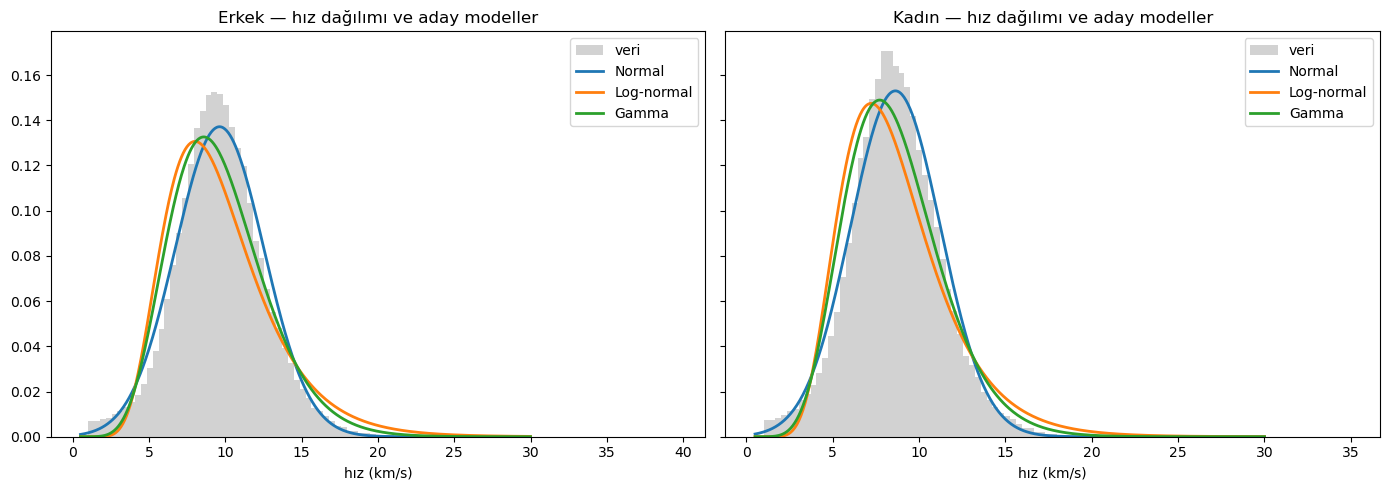

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x_grid = np.linspace(0.5, 30, 500)

for ax, g, ad in zip(axes, [1, 2], ["Erkek", "Kadın"]):
    v = gs_train.loc[gs_train["gender"] == g, "speed_kmh"].values

    ax.hist(v, bins=100, density=True, alpha=0.35, color="gray", label="veri")

    mu, sigma = v.mean(), v.std()
    ax.plot(x_grid, stats.norm.pdf(x_grid, mu, sigma), lw=2, label="Normal")

    s, loc, scale = stats.lognorm.fit(v, floc=0)
    ax.plot(x_grid, stats.lognorm.pdf(x_grid, s, loc, scale), lw=2, label="Log-normal")

    a, loc, scale = stats.gamma.fit(v, floc=0)
    ax.plot(x_grid, stats.gamma.pdf(x_grid, a, loc, scale), lw=2, label="Gamma")

    ax.set_title(f"{ad} — hız dağılımı ve aday modeller")
    ax.set_xlabel("hız (km/s)")
    ax.legend()

plt.tight_layout()
plt.show()

Kararı netleştirmek için Q-Q plot çizdim: ham hız normal doğrusundan kuyruklarda sapıyor, $\ln(hız)$ ise düz çizgiye oturuyor. Kararım: Log-normal  yani $\ln(hız)$ üzerinde Gaussian çalışacağım. Bu seçim hesabı da basitleştiriyor: log uzayında klasik Gaussian NB'ye dönüşüyor.

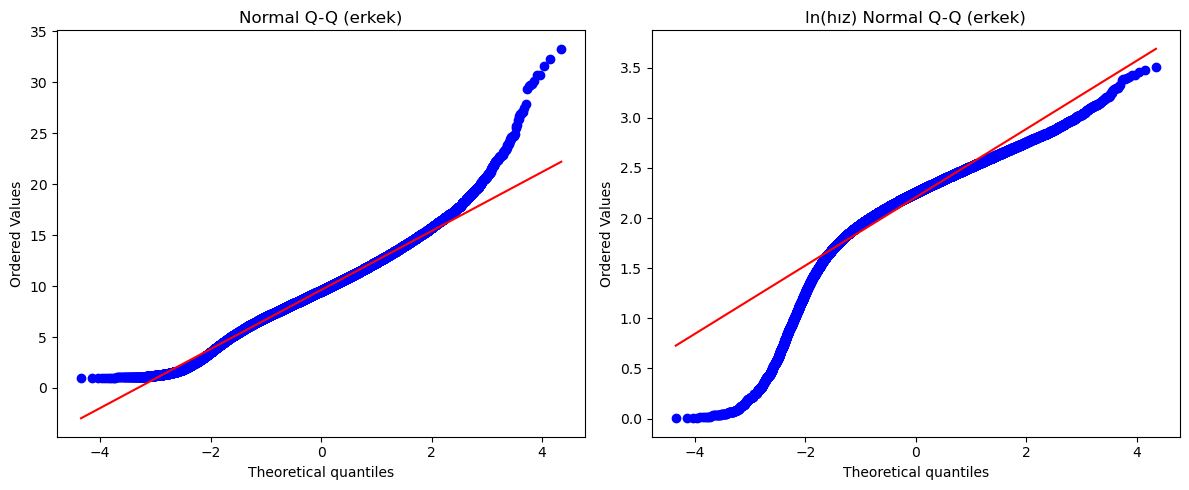

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
v = gs_train.loc[gs_train["gender"] == 1, "speed_kmh"].values[:100000]
stats.probplot(v, dist="norm", plot=axes[0]);  axes[0].set_title("Normal Q-Q (erkek)")
stats.probplot(np.log(v), dist="norm", plot=axes[1]); axes[1].set_title("ln(hız) Normal Q-Q (erkek)")
plt.tight_layout(); plt.show()

Train'den her sınıfın prior'ını ve $\ln(hız)$ için $(\mu_a, \sigma_a)$ parametrelerini tahmin ettim; `posterior_female` fonksiyonu Bayes kuralını doğrudan uyguluyor.

In [47]:
params, priors = {}, {}
n_train = len(gs_train)

for g in [1, 2]:
    lnv = np.log(gs_train.loc[gs_train["gender"] == g, "speed_kmh"].values)
    params[g] = (lnv.mean(), lnv.std())
    priors[g] = (gs_train["gender"] == g).mean()

print("Priorlar:", {g: round(p, 4) for g, p in priors.items()})
print("ln(hız) parametreleri (mu, sigma):", {g: tuple(round(x, 4) for x in p) for g, p in params.items()})

def posterior_female(speed):
    """P(gender=2 | speed) — log-normal likelihood ile"""
    lx = np.log(speed)
    like = {g: stats.norm.pdf(lx, params[g][0], params[g][1]) for g in [1, 2]}
    num = priors[2] * like[2]
    den = priors[1] * like[1] + priors[2] * like[2]
    return num / den

Priorlar: {1: np.float64(0.7599), 2: np.float64(0.2401)}
ln(hız) parametreleri (mu, sigma): {1: (np.float64(2.2085), np.float64(0.3577)), 2: (np.float64(2.1012), np.float64(0.3521))}


Değerlendirme: sınıflar dengesiz olduğu için düz accuracy yanıltıcı olur  "hep erkek" diyen bir model bile %76 tutturur. Bu yüzden ROC AUC ve balanced accuracy raporladım.

Sonuç: **AUC 0.605** hız, rastgele tahminden anlamlı ölçüde iyi bilgi taşıyor. Ama posterior hiçbir hız değerinde 0.5 eşiğini aşamadığı için argmax sınıflandırıcı her gözleme "erkek" diyor (accuracy = baseline = 0.761, confusion matrix'in kadın sütunu boş). Bunu modelin hatası olarak değil şöyle yorumladım: prior P(kadın) ≈ 0.24'ten başlıyor ve tek feature'ın likelihood oranı bu açığı kapatacak güçte değil. Kalibre bir posterior'un dengesiz prior + zayıf sinyal altındaki rasyonel davranışı bu.

In [48]:
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, accuracy_score, confusion_matrix

p_female = posterior_female(gs_test["speed_kmh"].values)
y_true   = (gs_test["gender"] == 2).astype(int)

y_pred = (p_female > 0.5).astype(int)         

print(f"Accuracy          : {accuracy_score(y_true, y_pred):.4f}")
print(f"Baseline (hep erkek): {(y_true == 0).mean():.4f}")
print(f"Balanced accuracy : {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"ROC AUC           : {roc_auc_score(y_true, p_female):.4f}")
print("\nConfusion matrix:\n", confusion_matrix(y_true, y_pred))

Accuracy          : 0.7585
Baseline (hep erkek): 0.7599
Balanced accuracy : 0.5001
ROC AUC           : 0.6056

Confusion matrix:
 [[151571    406]
 [ 47886    137]]


Türetimimin doğruluğunu test etmek istedim: aynı modeli sklearn `GaussianNB` ile $\ln(hız)$ üzerinde kurdum. Posterior'lar arasındaki maksimum fark 0.000000 — elle kurduğum sürekli-değişken genişletmesi sklearn'in implementasyonuyla bire bir aynı.

In [49]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(np.log(gs_train[["speed_kmh"]]), gs_train["gender"])
p_sk = gnb.predict_proba(np.log(gs_test[["speed_kmh"]]))[:, 1] 

print(f"sklearn ROC AUC : {roc_auc_score(y_true, p_sk):.4f}")
print(f"Elle vs sklearn posterior maks fark: {np.abs(p_female - p_sk).max():.6f}")

sklearn ROC AUC : 0.6056
Elle vs sklearn posterior maks fark: 0.000000


Son olarak modelin karar mekanizmasını görselleştirdim: $P(kadın \mid hız)$ eğrisi hız arttıkça monoton düşüyor, prior çizgisi etrafında hareket ediyor ama 0.5'e hiç ulaşmıyor.

**Sonuç:** Hız tek başına cinsiyeti ayırt etmeye yetmiyor (AUC 0.605, dağılımlar çok örtüşük) ama model istatistiksel olarak doğru kurulmuş ve kalibre bir posterior üretiyor. Daha güçlü bir tahmin için hızın yanına ek feature'lar (yolculuk saati, üyelik tipi, mesafe) eklenmeli.

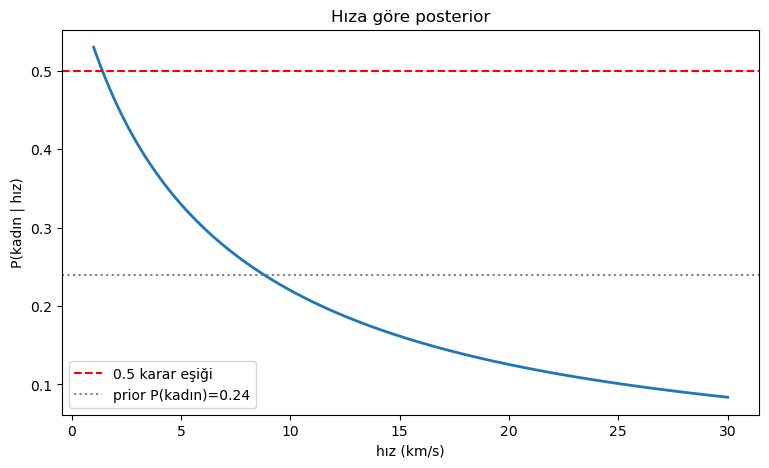

In [50]:
x = np.linspace(1, 30, 300)
plt.figure(figsize=(9, 5))
plt.plot(x, posterior_female(x), lw=2)
plt.axhline(0.5, ls="--", c="red", label="0.5 karar eşiği")
plt.axhline(priors[2], ls=":", c="gray", label=f"prior P(kadın)={priors[2]:.2f}")
plt.xlabel("hız (km/s)"); plt.ylabel("P(kadın | hız)")
plt.title("Hıza göre posterior")
plt.legend(); plt.show()